<a href="https://colab.research.google.com/github/sakkarchanda/ML_LAB/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Best K = 9


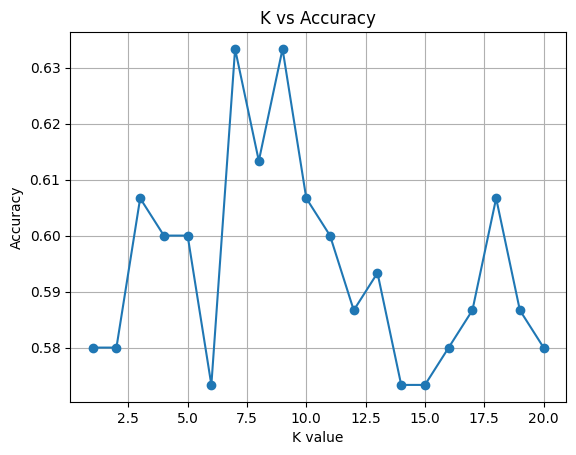

Test Accuracy = 0.8


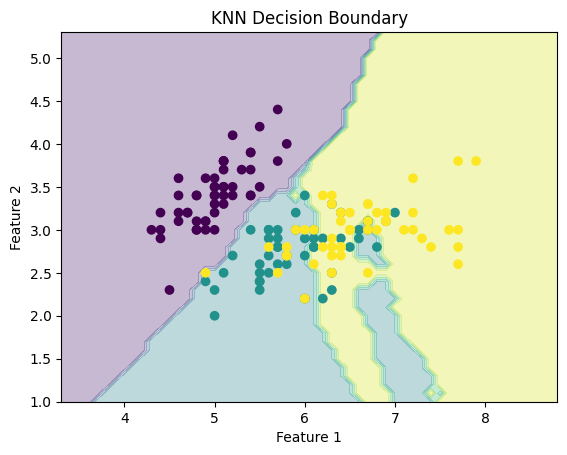

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from collections import Counter
data = load_iris()
X = data.data[:, :2]
y = data.target
def split(X, y, test_size=0.2):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    t = int(len(X) * test_size)
    return X[idx[t:]], X[idx[:t]], y[idx[t:]], y[idx[:t]]

X_train, X_test, y_train, y_test = split(X, y)

def dist(a, b):
    return np.sqrt(np.sum((a - b) ** 2))
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X = X
        self.y = y

    def predict(self, X):
        res = []
        for x in X:
            d = [dist(x, xi) for xi in self.X]
            idx = np.argsort(d)[:self.k]
            labels = [self.y[i] for i in idx]
            res.append(Counter(labels).most_common(1)[0][0])
        return np.array(res)
def acc(y1, y2):
    return np.sum(y1 == y2) / len(y1)
def cross_val(X, y, k_values, folds=5):
    fold_size = len(X) // folds
    scores = []
    for k in k_values:
        fold_acc = []
        for i in range(folds):
            start = i * fold_size
            end = start + fold_size

            X_val = X[start:end]
            y_val = y[start:end]

            X_tr = np.concatenate((X[:start], X[end:]), axis=0)
            y_tr = np.concatenate((y[:start], y[end:]), axis=0)

            model = KNN(k)
            model.fit(X_tr, y_tr)

            pred = model.predict(X_val)
            fold_acc.append(acc(y_val, pred))

        scores.append(np.mean(fold_acc))

    return scores

k_values = list(range(1, 21))
scores = cross_val(X, y, k_values)

best_k = k_values[np.argmax(scores)]
print("Best K =", best_k)
plt.figure()
plt.plot(k_values, scores, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.grid()
plt.show()
model = KNN(best_k)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Test Accuracy =", acc(y_test, pred))
h = 0.1
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")
plt.show()